# Kalenjin Common Voice Corpus - Exploratory Data Analysis

This notebook provides a comprehensive PhD-level exploratory data analysis of the Kalenjin Common Voice corpus for ASR development.

## Dataset Overview
- **Language**: Kalenjin (kln)
- **Source**: Mozilla Common Voice v24.0
- **Total Audio Clips**: 70,200
- **Purpose**: Automatic Speech Recognition (ASR) system development

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import soundfile as sf
from pathlib import Path
import warnings
from collections import Counter
import re
from scipy import stats
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Set paths
DATA_PATH = Path('../cv-corpus-24.0-2025-12-05-kln/cv-corpus-24.0-2025-12-05/kln')
CLIPS_PATH = DATA_PATH / 'clips'

print(f"Data path exists: {DATA_PATH.exists()}")
print(f"Clips path exists: {CLIPS_PATH.exists()}")

Data path exists: True
Clips path exists: True


## 1. Dataset Structure Analysis

In [2]:
# Load all TSV files
files = {
    'train': pd.read_csv(DATA_PATH / 'train.tsv', sep='\t'),
    'dev': pd.read_csv(DATA_PATH / 'dev.tsv', sep='\t'),
    'test': pd.read_csv(DATA_PATH / 'test.tsv', sep='\t'),
    'validated': pd.read_csv(DATA_PATH / 'validated.tsv', sep='\t'),
    'invalidated': pd.read_csv(DATA_PATH / 'invalidated.tsv', sep='\t'),
    'other': pd.read_csv(DATA_PATH / 'other.tsv', sep='\t'),
    'clip_durations': pd.read_csv(DATA_PATH / 'clip_durations.tsv', sep='\t')
}

# Dataset split sizes
split_sizes = {name: len(df) for name, df in files.items()}
print("Dataset Split Sizes:")
for name, size in split_sizes.items():
    print(f"{name:15}: {size:,} samples")

total_samples = sum(split_sizes.values()) - len(files['clip_durations'])
print(f"\nTotal unique samples: {total_samples:,}")

Dataset Split Sizes:
train          : 11,065 samples
dev            : 6,412 samples
test           : 5,685 samples
validated      : 31,532 samples
invalidated    : 537 samples
other          : 37,348 samples
clip_durations : 70,200 samples

Total unique samples: 92,579


In [3]:
# Display detailed information about each dataset
print("\n" + "="*80)
print("DETAILED DATAFRAME INFORMATION")
print("="*80)

for name, df in files.items():
    print(f"\n{'='*80}")
    print(f"Dataset: {name.upper()}")
    print(f"{'='*80}")
    print(f"\nShape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"\nColumns: {list(df.columns)}")
    print(f"\nData Types:\n{df.dtypes}")
    print(f"\nMissing Values:\n{df.isnull().sum()}")
    print(f"\nFirst 3 rows:")
    display(df.head(3))
    print(f"\nBasic Statistics:")
    display(df.describe(include='all'))


DETAILED DATAFRAME INFORMATION

Dataset: TRAIN

Shape: 11065 rows × 13 columns

Columns: ['client_id', 'path', 'sentence_id', 'sentence', 'sentence_domain', 'up_votes', 'down_votes', 'age', 'gender', 'accents', 'variant', 'locale', 'segment']

Data Types:
client_id           object
path                object
sentence_id         object
sentence            object
sentence_domain     object
up_votes             int64
down_votes           int64
age                 object
gender              object
accents            float64
variant            float64
locale              object
segment            float64
dtype: object

Missing Values:
client_id              0
path                   0
sentence_id            0
sentence               0
sentence_domain        0
up_votes               0
down_votes             0
age                    5
gender              2044
accents            11065
variant            11065
locale                 0
segment            11065
dtype: int64

First 3 rows:


,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment
0,973c5264074311e3f98c81150ac446a06e9e102a82d68d...,common_voice_kln_40550981.mp3,215333f4165d4472d76c3ea84967fee273204e493af072...,Tomo itinye choruet ne chepto iman?,general,3,0,twenties,female_feminine,NaN,NaN,kln,NaN
1,973c5264074311e3f98c81150ac446a06e9e102a82d68d...,common_voice_kln_40550983.mp3,2d4f39b048a345f2ad77a4fdb5e74d14ed39f5a5d16e5a...,Teret nigiteer ko nenyu,general,2,0,twenties,female_feminine,NaN,NaN,kln,NaN
2,973c5264074311e3f98c81150ac446a06e9e102a82d68d...,common_voice_kln_40550984.mp3,2bc69029ab8a4b147e58c37f1ccf13f1e104bc4fedc2fb...,kiyaat baruet Eng' kasarta ne kimito inegei,general,2,0,twenties,female_feminine,NaN,NaN,kln,NaN



Basic Statistics:


,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment
count,11065,11065,11065,11065,11065,11065.000000,11065.000000,11060,9021,0.0,0.0,11065,0.0
unique,5,11065,11065,11065,8,NaN,NaN,2,1,NaN,NaN,1,NaN
top,90c7e694223d4c28d1ec8924c7acfe005f9fb870f1ba7a...,common_voice_kln_40550981.mp3,215333f4165d4472d76c3ea84967fee273204e493af072...,Tomo itinye choruet ne chepto iman?,general,NaN,NaN,twenties,female_feminine,NaN,NaN,kln,NaN
freq,3990,1,1,1,10865,NaN,NaN,7075,9021,NaN,NaN,11065,NaN
mean,NaN,NaN,NaN,NaN,NaN,2.105920,0.030005,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,0.346695,0.172189,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,2.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,2.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,2.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,2.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN



Dataset: DEV

Shape: 6412 rows × 13 columns

Columns: ['client_id', 'path', 'sentence_id', 'sentence', 'sentence_domain', 'up_votes', 'down_votes', 'age', 'gender', 'accents', 'variant', 'locale', 'segment']

Data Types:
client_id           object
path                object
sentence_id         object
sentence            object
sentence_domain     object
up_votes             int64
down_votes           int64
age                 object
gender              object
accents            float64
variant            float64
locale              object
segment            float64
dtype: object

Missing Values:
client_id             0
path                  0
sentence_id           0
sentence              0
sentence_domain       0
up_votes              0
down_votes            0
age                  30
gender             1368
accents            6412
variant            6412
locale                0
segment            6412
dtype: int64

First 3 rows:


...

,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment
count,37348,37348,37348,37348,37344,37348.000000,37348.000000,36808,27317,0.0,0.0,37348,0.0
unique,39,37348,26191,25577,10,NaN,NaN,4,2,NaN,NaN,1,NaN
top,90c7e694223d4c28d1ec8924c7acfe005f9fb870f1ba7a...,common_voice_kln_40297139.mp3,008fbb37c349217b4eb477ca5ec1bb6c0e8daabdc3456c...,Kechop amitwogik eng kipakenge kotechei chorwa...,general,NaN,NaN,twenties,female_feminine,NaN,NaN,kln,NaN
freq,11942,1,4,5,36671,NaN,NaN,20169,25423,NaN,NaN,37348,NaN
mean,NaN,NaN,NaN,NaN,NaN,0.465380,0.045973,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,0.498807,0.209429,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN



Dataset: CLIP_DURATIONS

Shape: 70200 rows × 2 columns

Columns: ['clip', 'duration[ms]']

Data Types:
clip            object
duration[ms]     int64
dtype: object

Missing Values:
clip            0
duration[ms]    0
dtype: int64

First 3 rows:


,clip,duration[ms]
0,common_voice_kln_40606097.mp3,4788
1,common_voice_kln_40601541.mp3,3708
2,common_voice_kln_40606364.mp3,4716



Basic Statistics:


,clip,duration[ms]
count,70200,70200.000000
unique,70200,NaN
top,common_voice_kln_40606097.mp3,NaN
freq,1,NaN
mean,NaN,4705.036410
std,NaN,4396.854003
min,NaN,1260.000000
25%,NaN,3168.000000
50%,NaN,3996.000000
75%,NaN,5400.000000


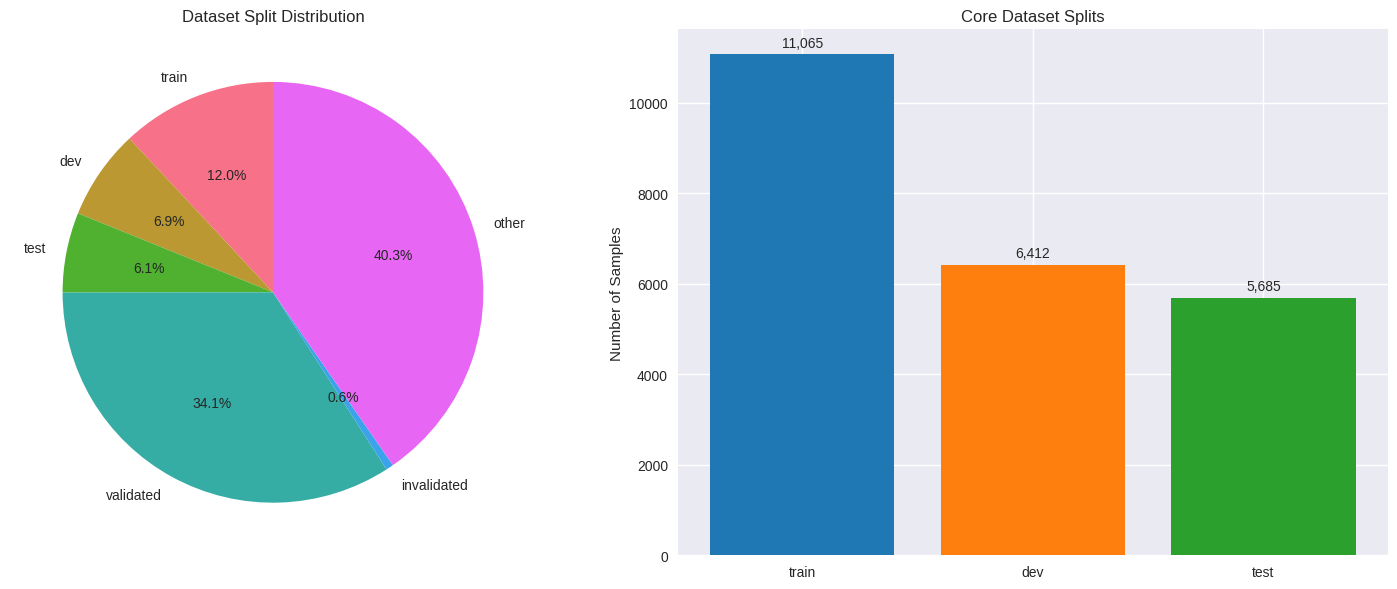

In [4]:
# Visualize dataset splits
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart of all splits
split_data = {k: v for k, v in split_sizes.items() if k != 'clip_durations'}
ax1.pie(split_data.values(), labels=split_data.keys(), autopct='%1.1f%%', startangle=90)
ax1.set_title('Dataset Split Distribution')

# Bar chart focusing on train/dev/test
core_splits = ['train', 'dev', 'test']
core_data = [split_sizes[split] for split in core_splits]
bars = ax2.bar(core_splits, core_data, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax2.set_title('Core Dataset Splits')
ax2.set_ylabel('Number of Samples')

# Add value labels on bars
for bar, value in zip(bars, core_data):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
             f'{value:,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 2. Audio Duration Analysis

In [5]:
# Analyze clip durations
durations = files['clip_durations']
durations['duration_seconds'] = durations['duration[ms]'] / 1000  # Convert to seconds

# Duration statistics
duration_stats = durations['duration_seconds'].describe()
print("Audio Duration Statistics (seconds):")
print(duration_stats)
print(f"\nTotal audio duration: {durations['duration_seconds'].sum()/3600:.2f} hours")
print(f"Median duration: {durations['duration_seconds'].median():.2f} seconds")
print(f"Mode duration: {durations['duration_seconds'].mode().iloc[0]:.2f} seconds")

Audio Duration Statistics (seconds):
count    70200.000000
mean         4.705036
std          4.396854
min          1.260000
25%          3.168000
50%          3.996000
75%          5.400000
max        189.432000
Name: duration_seconds, dtype: float64

Total audio duration: 91.75 hours
Median duration: 4.00 seconds
Mode duration: 3.17 seconds


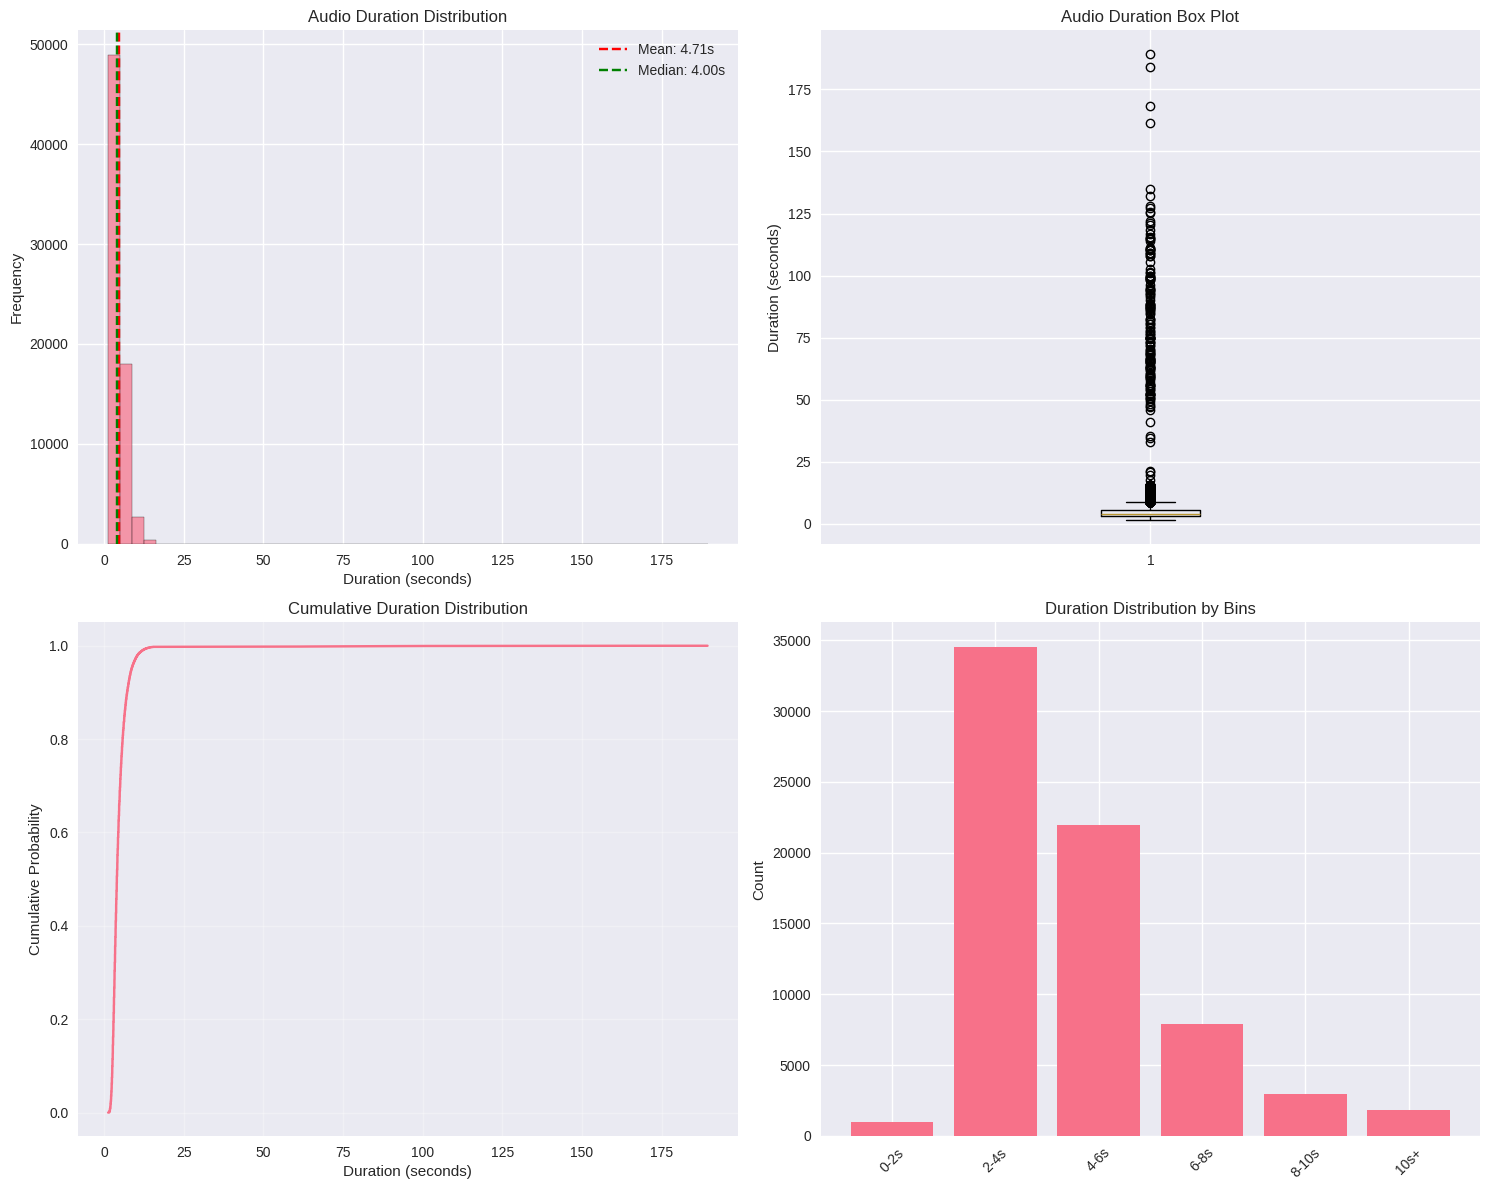


Duration Distribution by Bins:
0-2s: 1,004 clips (1.4%)
2-4s: 34,536 clips (49.2%)
4-6s: 21,981 clips (31.3%)
6-8s: 7,880 clips (11.2%)
8-10s: 2,978 clips (4.2%)
10s+: 1,821 clips (2.6%)


In [6]:
# Duration distribution visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Histogram
axes[0,0].hist(durations['duration_seconds'], bins=50, alpha=0.7, edgecolor='black')
axes[0,0].axvline(durations['duration_seconds'].mean(), color='red', linestyle='--', label=f'Mean: {durations["duration_seconds"].mean():.2f}s')
axes[0,0].axvline(durations['duration_seconds'].median(), color='green', linestyle='--', label=f'Median: {durations["duration_seconds"].median():.2f}s')
axes[0,0].set_title('Audio Duration Distribution')
axes[0,0].set_xlabel('Duration (seconds)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# Box plot
axes[0,1].boxplot(durations['duration_seconds'])
axes[0,1].set_title('Audio Duration Box Plot')
axes[0,1].set_ylabel('Duration (seconds)')

# Cumulative distribution
sorted_durations = np.sort(durations['duration_seconds'])
cumulative = np.arange(1, len(sorted_durations) + 1) / len(sorted_durations)
axes[1,0].plot(sorted_durations, cumulative)
axes[1,0].set_title('Cumulative Duration Distribution')
axes[1,0].set_xlabel('Duration (seconds)')
axes[1,0].set_ylabel('Cumulative Probability')
axes[1,0].grid(True, alpha=0.3)

# Duration bins analysis
bins = [0, 2, 4, 6, 8, 10, float('inf')]
labels = ['0-2s', '2-4s', '4-6s', '6-8s', '8-10s', '10s+']
duration_bins = pd.cut(durations['duration_seconds'], bins=bins, labels=labels)
bin_counts = duration_bins.value_counts().sort_index()

axes[1,1].bar(range(len(bin_counts)), bin_counts.values)
axes[1,1].set_xticks(range(len(bin_counts)))
axes[1,1].set_xticklabels(bin_counts.index, rotation=45)
axes[1,1].set_title('Duration Distribution by Bins')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("\nDuration Distribution by Bins:")
for label, count in bin_counts.items():
    percentage = (count / len(durations)) * 100
    print(f"{label}: {count:,} clips ({percentage:.1f}%)")

## 3. Text Analysis

In [7]:
# Combine all text data for comprehensive analysis
all_sentences = []
for split_name in ['train', 'dev', 'test', 'validated', 'other']:
    if 'sentence' in files[split_name].columns:
        all_sentences.extend(files[split_name]['sentence'].dropna().tolist())

# Remove duplicates while preserving order
unique_sentences = list(dict.fromkeys(all_sentences))
print(f"Total sentences (with duplicates): {len(all_sentences):,}")
print(f"Unique sentences: {len(unique_sentences):,}")
print(f"Duplication rate: {((len(all_sentences) - len(unique_sentences)) / len(all_sentences) * 100):.1f}%")

Total sentences (with duplicates): 92,042
Unique sentences: 29,096
Duplication rate: 68.4%


In [8]:
# Text length analysis
sentence_lengths = [len(sentence) for sentence in unique_sentences]
word_counts = [len(sentence.split()) for sentence in unique_sentences]

print("Text Length Statistics:")
print(f"Character length - Mean: {np.mean(sentence_lengths):.1f}, Median: {np.median(sentence_lengths):.1f}")
print(f"Word count - Mean: {np.mean(word_counts):.1f}, Median: {np.median(word_counts):.1f}")
print(f"Shortest sentence: {min(sentence_lengths)} characters")
print(f"Longest sentence: {max(sentence_lengths)} characters")
print(f"Min words: {min(word_counts)}, Max words: {max(word_counts)}")

Text Length Statistics:
Character length - Mean: 53.1, Median: 38.0
Word count - Mean: 6.8, Median: 6.0
Shortest sentence: 3 characters
Longest sentence: 123489 characters
Min words: 1, Max words: 6170


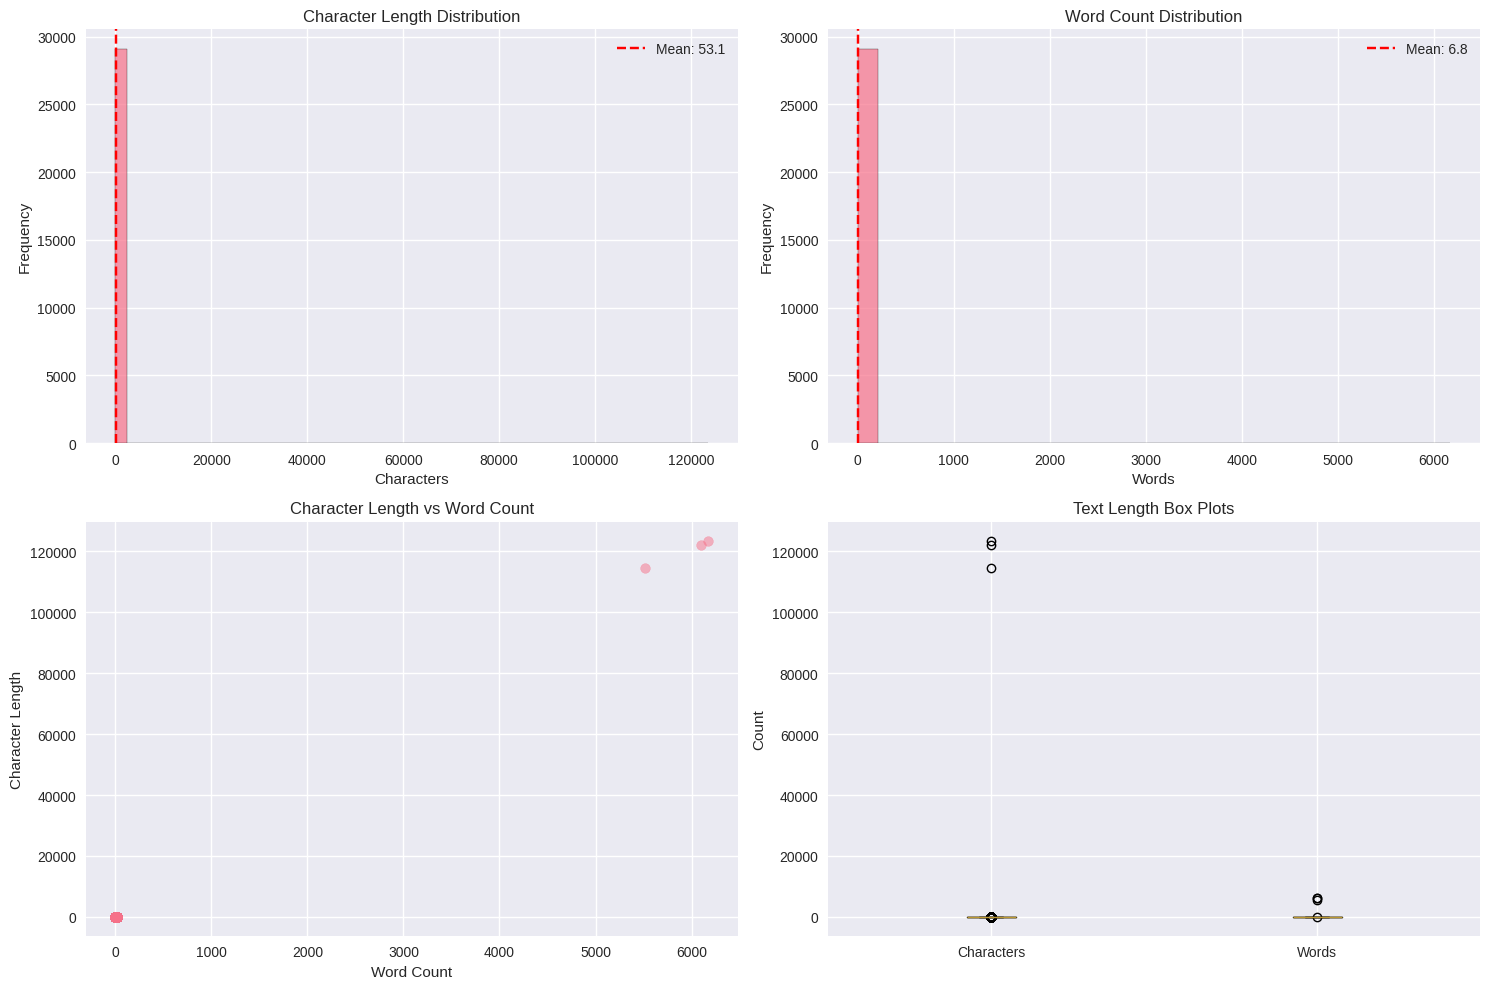

In [9]:
# Text length distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Character length distribution
axes[0,0].hist(sentence_lengths, bins=50, alpha=0.7, edgecolor='black')
axes[0,0].axvline(np.mean(sentence_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(sentence_lengths):.1f}')
axes[0,0].set_title('Character Length Distribution')
axes[0,0].set_xlabel('Characters')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# Word count distribution
axes[0,1].hist(word_counts, bins=30, alpha=0.7, edgecolor='black')
axes[0,1].axvline(np.mean(word_counts), color='red', linestyle='--', label=f'Mean: {np.mean(word_counts):.1f}')
axes[0,1].set_title('Word Count Distribution')
axes[0,1].set_xlabel('Words')
axes[0,1].set_ylabel('Frequency')
axes[0,1].legend()

# Character vs Word count scatter
axes[1,0].scatter(word_counts, sentence_lengths, alpha=0.5)
axes[1,0].set_title('Character Length vs Word Count')
axes[1,0].set_xlabel('Word Count')
axes[1,0].set_ylabel('Character Length')

# Box plots
box_data = [sentence_lengths, word_counts]
axes[1,1].boxplot(box_data, labels=['Characters', 'Words'])
axes[1,1].set_title('Text Length Box Plots')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 4. Linguistic Analysis

Top 20 Most Frequent Characters:
 1. 'e': 145,112 (12.14%)
 2. 'i': 121,994 (10.20%)
 3. 'a': 119,555 (10.00%)
 4. 'k': 109,378 (9.15%)
 5. 'o': 98,115 (8.21%)
 6. 'n': 96,849 (8.10%)
 7. 't': 75,948 (6.35%)
 8. 'b': 44,866 (3.75%)
 9. 'c': 44,184 (3.70%)
10. 'm': 43,700 (3.66%)
11. 'u': 39,703 (3.32%)
12. 'g': 39,387 (3.29%)
13. 'h': 32,948 (2.76%)
14. 's': 31,344 (2.62%)
15. 'r': 30,885 (2.58%)
16. 'l': 27,003 (2.26%)
17. 'y': 25,837 (2.16%)
18. 'd': 20,574 (1.72%)
19. 'f': 17,068 (1.43%)
20. 'w': 14,660 (1.23%)


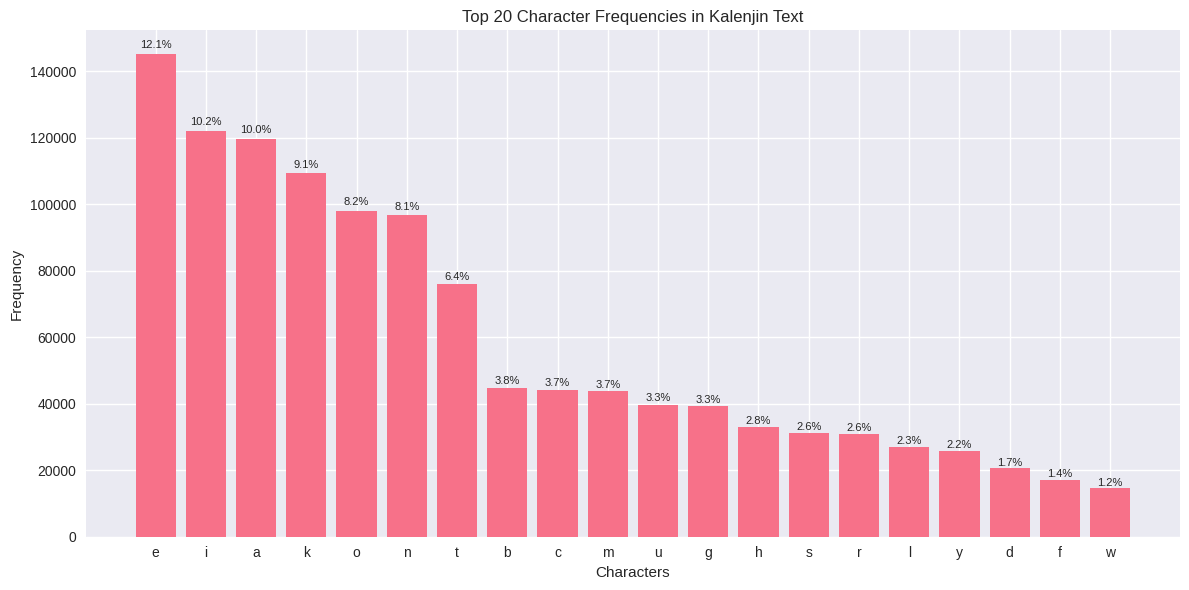

In [10]:
# Character frequency analysis
all_text = ' '.join(unique_sentences).lower()
char_freq = Counter(all_text)

# Remove spaces and get alphabetic characters
alphabetic_chars = {char: count for char, count in char_freq.items() if char.isalpha()}
sorted_chars = sorted(alphabetic_chars.items(), key=lambda x: x[1], reverse=True)

print("Top 20 Most Frequent Characters:")
for i, (char, count) in enumerate(sorted_chars[:20]):
    percentage = (count / sum(alphabetic_chars.values())) * 100
    print(f"{i+1:2d}. '{char}': {count:,} ({percentage:.2f}%)")

# Character frequency visualization
top_chars = sorted_chars[:20]
chars, counts = zip(*top_chars)

plt.figure(figsize=(12, 6))
bars = plt.bar(chars, counts)
plt.title('Top 20 Character Frequencies in Kalenjin Text')
plt.xlabel('Characters')
plt.ylabel('Frequency')
plt.xticks(rotation=0)

# Add percentage labels
total_chars = sum(alphabetic_chars.values())
for bar, count in zip(bars, counts):
    percentage = (count / total_chars) * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + count*0.01, 
             f'{percentage:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [11]:
# Word frequency analysis
all_words = []
for sentence in unique_sentences:
    words = sentence.lower().split()
    # Clean words (remove punctuation)
    clean_words = [re.sub(r'[^\w]', '', word) for word in words if re.sub(r'[^\w]', '', word)]
    all_words.extend(clean_words)

word_freq = Counter(all_words)
vocab_size = len(word_freq)
total_words = len(all_words)

print(f"Vocabulary Statistics:")
print(f"Total words (tokens): {total_words:,}")
print(f"Unique words (types): {vocab_size:,}")
print(f"Type-Token Ratio (TTR): {vocab_size/total_words:.4f}")

# Most frequent words
print("\nTop 30 Most Frequent Words:")
for i, (word, count) in enumerate(word_freq.most_common(30)):
    percentage = (count / total_words) * 100
    print(f"{i+1:2d}. '{word}': {count:,} ({percentage:.2f}%)")

Vocabulary Statistics:
Total words (tokens): 198,272
Unique words (types): 37,537
Type-Token Ratio (TTR): 0.1893

Top 30 Most Frequent Words:
 1. 'eng': 7,118 (3.59%)
 2. 'ko': 4,411 (2.22%)
 3. 'che': 3,597 (1.81%)
 4. 'ne': 3,424 (1.73%)
 5. 'ak': 2,872 (1.45%)
 6. 'ab': 2,786 (1.41%)
 7. 'nebo': 1,651 (0.83%)
 8. 'tugul': 1,292 (0.65%)
 9. 'kln': 1,174 (0.59%)
10. 'general': 1,147 (0.58%)
11. '0': 1,113 (0.56%)
12. 'twenties': 1,095 (0.55%)
13. 'kole': 1,083 (0.55%)
14. 'biik': 1,074 (0.54%)
15. '2': 1,063 (0.54%)
16. 'chechang': 990 (0.50%)
17. 'emet': 951 (0.48%)
18. 'female_feminine': 707 (0.36%)
19. 'bo': 702 (0.35%)
20. 'en': 664 (0.33%)
21. 'chang': 661 (0.33%)
22. 'chebo': 644 (0.32%)
23. 'bik': 643 (0.32%)
24. 'fa9a0bd5a48a5f855583123eecb97fe355e56fcf6f54c52e2e91303e967d0542b53fb12f5c54c8944723d1ed2aaf316e35cdf66281b290a6a72c670b0db1b968': 643 (0.32%)
25. 'oret': 634 (0.32%)
26. 'mising': 628 (0.32%)
27. 'age': 621 (0.31%)
28. 'amu': 616 (0.31%)
29. 'tos': 582 (0.29%)
30. 'i

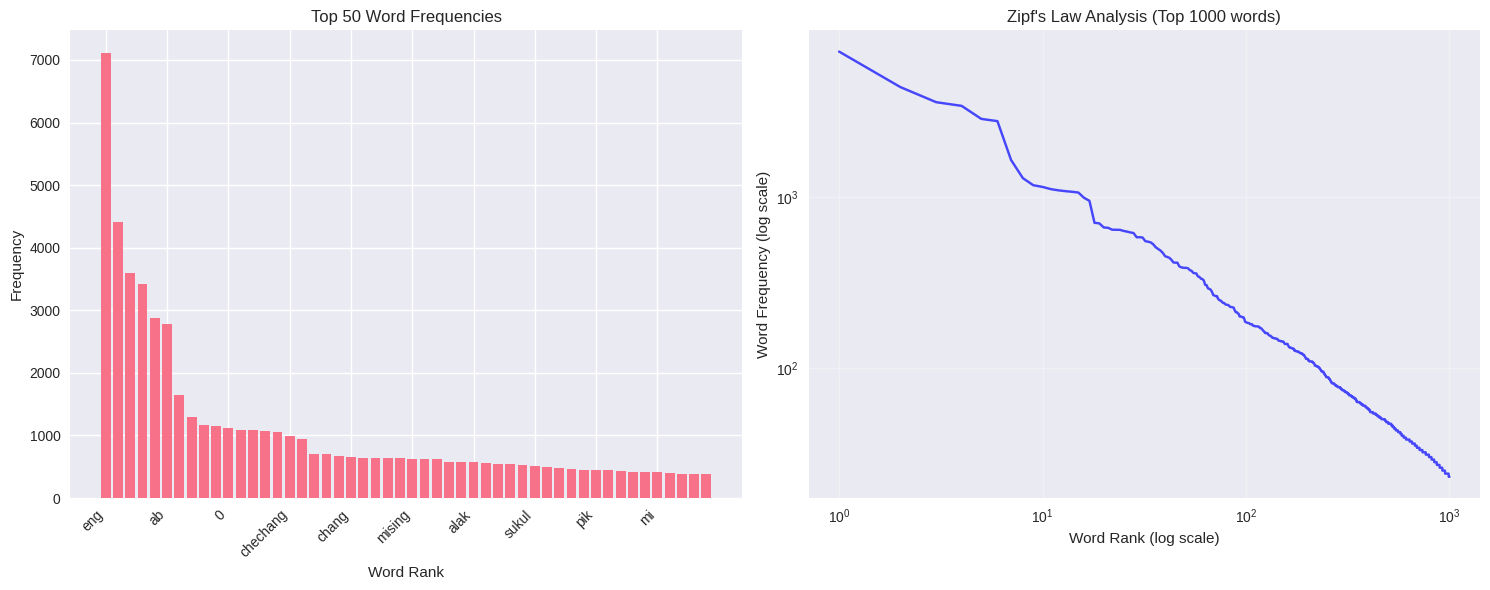


Vocabulary Coverage Analysis:
50% coverage requires top 428 words (1.1% of vocabulary)
80% coverage requires top 6,396 words (17.0% of vocabulary)
90% coverage requires top 17,710 words (47.2% of vocabulary)
95% coverage requires top 27,624 words (73.6% of vocabulary)
99% coverage requires top 35,555 words (94.7% of vocabulary)


In [12]:
# Word frequency distribution (Zipf's law analysis)
word_counts = list(word_freq.values())
word_counts.sort(reverse=True)
ranks = range(1, len(word_counts) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Top 50 words frequency
top_words = word_freq.most_common(50)
words, counts = zip(*top_words)
ax1.bar(range(len(words)), counts)
ax1.set_title('Top 50 Word Frequencies')
ax1.set_xlabel('Word Rank')
ax1.set_ylabel('Frequency')
ax1.set_xticks(range(0, len(words), 5))
ax1.set_xticklabels([words[i] for i in range(0, len(words), 5)], rotation=45, ha='right')

# Zipf's law (log-log plot)
ax2.loglog(ranks[:1000], word_counts[:1000], 'b-', alpha=0.7)
ax2.set_title("Zipf's Law Analysis (Top 1000 words)")
ax2.set_xlabel('Word Rank (log scale)')
ax2.set_ylabel('Word Frequency (log scale)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Vocabulary coverage analysis
cumulative_freq = np.cumsum(word_counts)
coverage_percentages = [50, 80, 90, 95, 99]
print("\nVocabulary Coverage Analysis:")
for percentage in coverage_percentages:
    threshold = total_words * (percentage / 100)
    words_needed = np.searchsorted(cumulative_freq, threshold) + 1
    print(f"{percentage}% coverage requires top {words_needed:,} words ({words_needed/vocab_size*100:.1f}% of vocabulary)")

## 5. Speaker Demographics Analysis

In [13]:
# Analyze speaker demographics from validated data
validated_df = files['validated']

# Speaker statistics
unique_speakers = validated_df['client_id'].nunique()
total_recordings = len(validated_df)
avg_recordings_per_speaker = total_recordings / unique_speakers

print(f"Speaker Statistics:")
print(f"Unique speakers: {unique_speakers:,}")
print(f"Total recordings: {total_recordings:,}")
print(f"Average recordings per speaker: {avg_recordings_per_speaker:.1f}")

# Recordings per speaker distribution
speaker_counts = validated_df['client_id'].value_counts()
print(f"\nRecordings per speaker statistics:")
print(f"Min: {speaker_counts.min()}")
print(f"Max: {speaker_counts.max()}")
print(f"Median: {speaker_counts.median()}")
print(f"Mean: {speaker_counts.mean():.1f}")

Speaker Statistics:
Unique speakers: 39
Total recordings: 31,532
Average recordings per speaker: 808.5

Recordings per speaker statistics:
Min: 1
Max: 8092
Median: 149.0
Mean: 808.5


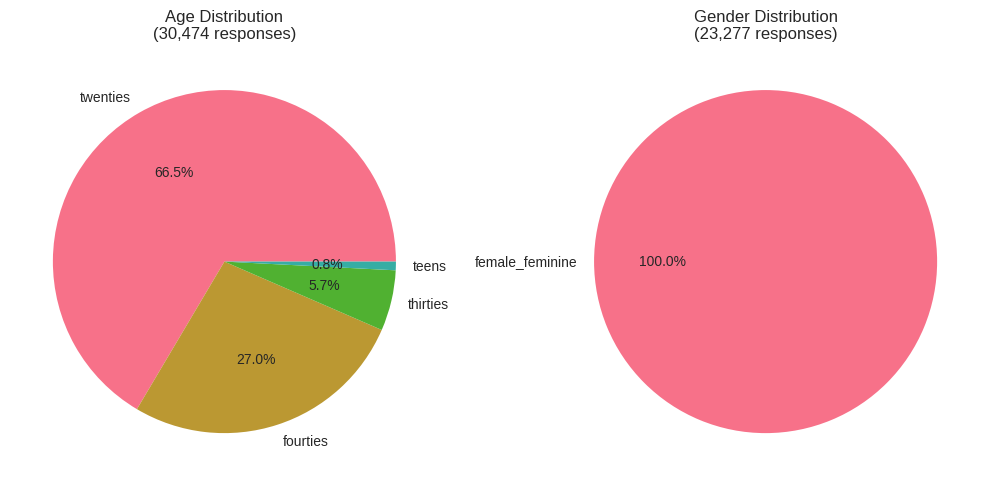


Age Distribution:
  twenties: 20,260 (66.5%)
  fourties: 8,226 (27.0%)
  thirties: 1,741 (5.7%)
  teens: 247 (0.8%)
  Missing: 1,058 (3.4%)

Gender Distribution:
  female_feminine: 23,277 (100.0%)
  Missing: 8,255 (26.2%)


In [14]:
# Demographics analysis
demographic_cols = ['age', 'gender', 'accent']
available_demographics = [col for col in demographic_cols if col in validated_df.columns]

if available_demographics:
    fig, axes = plt.subplots(1, len(available_demographics), figsize=(5*len(available_demographics), 5))
    if len(available_demographics) == 1:
        axes = [axes]
    
    for i, col in enumerate(available_demographics):
        # Count non-null values
        col_data = validated_df[col].dropna()
        if len(col_data) > 0:
            value_counts = col_data.value_counts()
            axes[i].pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%')
            axes[i].set_title(f'{col.capitalize()} Distribution\n({len(col_data):,} responses)')
        else:
            axes[i].text(0.5, 0.5, f'No {col} data available', ha='center', va='center')
            axes[i].set_title(f'{col.capitalize()} Distribution')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed demographics
    for col in available_demographics:
        col_data = validated_df[col].dropna()
        if len(col_data) > 0:
            print(f"\n{col.capitalize()} Distribution:")
            value_counts = col_data.value_counts()
            for value, count in value_counts.items():
                percentage = (count / len(col_data)) * 100
                print(f"  {value}: {count:,} ({percentage:.1f}%)")
            print(f"  Missing: {len(validated_df) - len(col_data):,} ({((len(validated_df) - len(col_data))/len(validated_df)*100):.1f}%)")
else:
    print("No demographic data available in the dataset.")

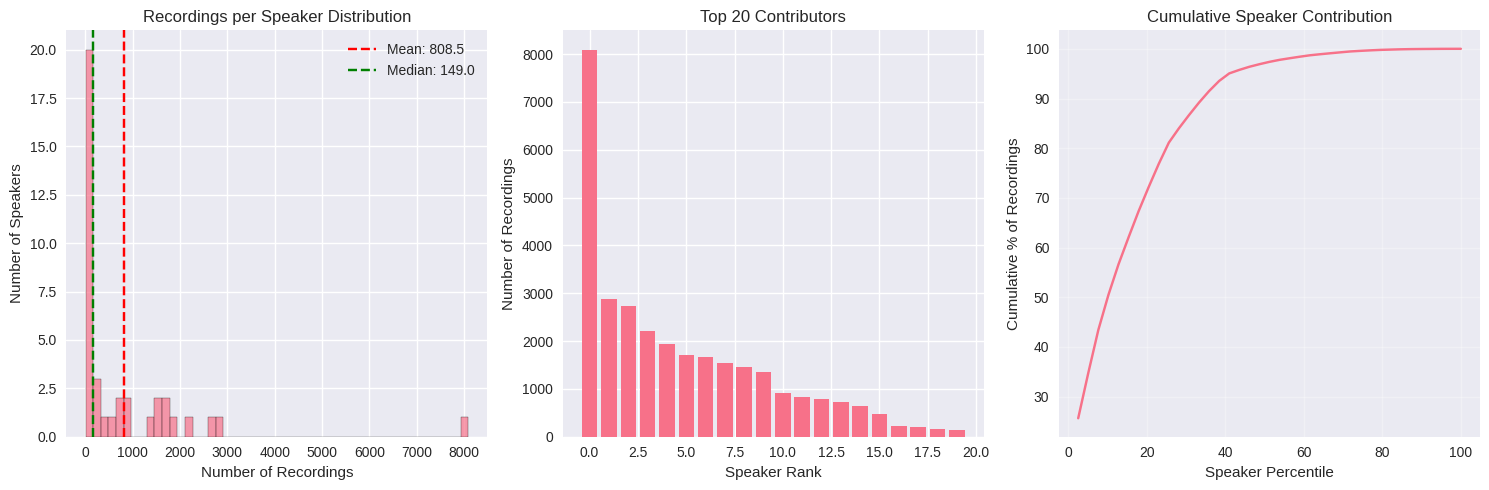


Speaker Contribution Analysis:
Top 10% of speakers (3) contribute 13,698 recordings (43.4%)
Gini coefficient (speaker inequality): 0.710 (0=perfect equality, 1=perfect inequality)


In [15]:
# Speaker contribution analysis
plt.figure(figsize=(15, 5))

# Distribution of recordings per speaker
plt.subplot(1, 3, 1)
plt.hist(speaker_counts.values, bins=50, alpha=0.7, edgecolor='black')
plt.axvline(speaker_counts.mean(), color='red', linestyle='--', label=f'Mean: {speaker_counts.mean():.1f}')
plt.axvline(speaker_counts.median(), color='green', linestyle='--', label=f'Median: {speaker_counts.median():.1f}')
plt.title('Recordings per Speaker Distribution')
plt.xlabel('Number of Recordings')
plt.ylabel('Number of Speakers')
plt.legend()

# Top contributors
plt.subplot(1, 3, 2)
top_contributors = speaker_counts.head(20)
plt.bar(range(len(top_contributors)), top_contributors.values)
plt.title('Top 20 Contributors')
plt.xlabel('Speaker Rank')
plt.ylabel('Number of Recordings')

# Cumulative contribution
plt.subplot(1, 3, 3)
cumulative_recordings = np.cumsum(speaker_counts.values)
speaker_percentiles = np.arange(1, len(speaker_counts) + 1) / len(speaker_counts) * 100
plt.plot(speaker_percentiles, cumulative_recordings / total_recordings * 100)
plt.title('Cumulative Speaker Contribution')
plt.xlabel('Speaker Percentile')
plt.ylabel('Cumulative % of Recordings')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Speaker contribution insights
top_10_percent = int(unique_speakers * 0.1)
top_10_contribution = speaker_counts.head(top_10_percent).sum()
print(f"\nSpeaker Contribution Analysis:")
print(f"Top 10% of speakers ({top_10_percent:,}) contribute {top_10_contribution:,} recordings ({top_10_contribution/total_recordings*100:.1f}%)")

# Gini coefficient for speaker distribution inequality
def gini_coefficient(x):
    sorted_x = np.sort(x)
    n = len(x)
    cumsum = np.cumsum(sorted_x)
    return (n + 1 - 2 * np.sum(cumsum) / cumsum[-1]) / n

gini = gini_coefficient(speaker_counts.values)
print(f"Gini coefficient (speaker inequality): {gini:.3f} (0=perfect equality, 1=perfect inequality)")

## 6. Audio Quality Analysis

In [16]:
# Sample audio files for quality analysis
import random
import os

# Get list of audio files
audio_files = list(CLIPS_PATH.glob('*.mp3'))
print(f"Total audio files found: {len(audio_files):,}")

# Sample random files for analysis (limit to avoid memory issues)
sample_size = min(1000, len(audio_files))
sampled_files = random.sample(audio_files, sample_size)
print(f"Analyzing sample of {sample_size} files...")

# Analyze audio properties
audio_properties = []
failed_files = []

for i, file_path in enumerate(sampled_files[:100]):  # Limit for demo
    try:
        # Load audio file
        y, sr = librosa.load(file_path, sr=None)
        
        # Calculate properties
        duration = len(y) / sr
        rms_energy = np.sqrt(np.mean(y**2))
        zero_crossing_rate = np.mean(librosa.feature.zero_crossing_rate(y))
        spectral_centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
        
        audio_properties.append({
            'file': file_path.name,
            'duration': duration,
            'sample_rate': sr,
            'rms_energy': rms_energy,
            'zero_crossing_rate': zero_crossing_rate,
            'spectral_centroid': spectral_centroid
        })
        
        if (i + 1) % 25 == 0:
            print(f"Processed {i + 1} files...")
            
    except Exception as e:
        failed_files.append((file_path.name, str(e)))

audio_df = pd.DataFrame(audio_properties)
print(f"\nSuccessfully analyzed: {len(audio_df)} files")
print(f"Failed to analyze: {len(failed_files)} files")

if len(audio_df) > 0:
    print("\nAudio Quality Statistics:")
    print(audio_df.describe())

Total audio files found: 70,200
Analyzing sample of 1000 files...
Processed 25 files...
Processed 50 files...
Processed 75 files...
Processed 100 files...

Successfully analyzed: 100 files
Failed to analyze: 0 files

Audio Quality Statistics:
         duration  sample_rate  rms_energy  zero_crossing_rate  \
count  100.000000        100.0  100.000000          100.000000   
mean     4.570920      32000.0    0.091436            0.080029   
std      1.990103          0.0    0.050072            0.026103   
min      1.908000      32000.0    0.007041            0.024221   
25%      3.150000      32000.0    0.061720            0.061305   
50%      4.104000      32000.0    0.079979            0.079901   
75%      5.616000      32000.0    0.109179            0.094105   
max     12.060000      32000.0    0.247861            0.153740   

       spectral_centroid  
count         100.000000  
mean         1681.809772  
std           461.185553  
min           635.572825  
25%          1351.984325  


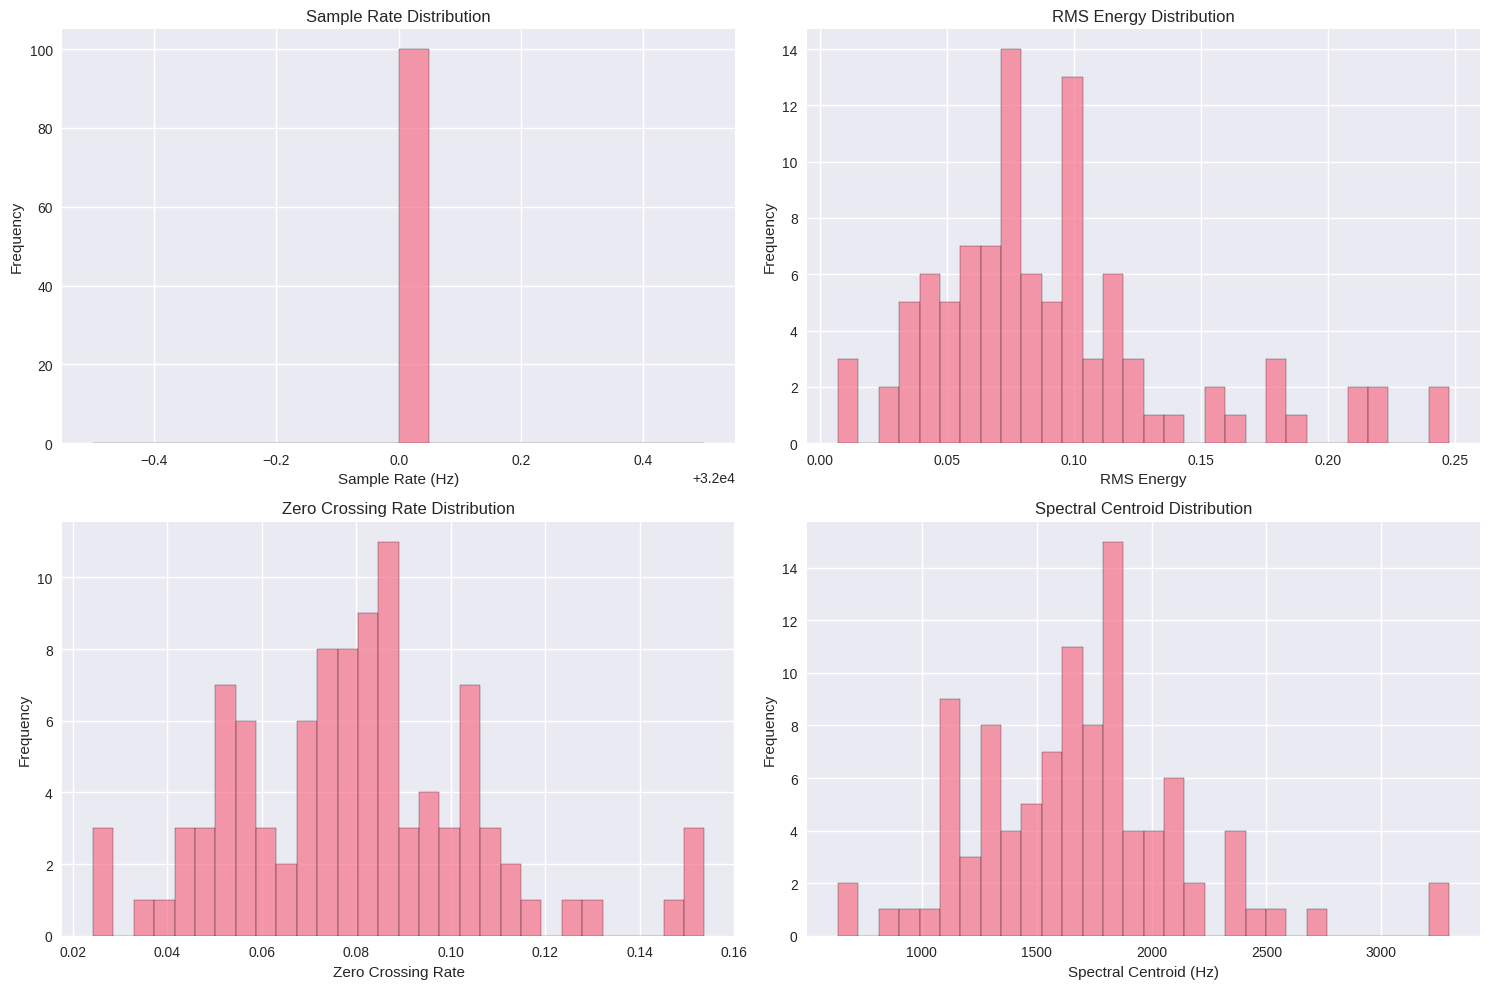


Audio Quality Assessment:
Sample rate consistency: 1 unique sample rates
Most common sample rate: 32000 Hz
Potentially low volume files: 5 (5.0%)
Potentially high volume files: 5 (5.0%)


In [17]:
if len(audio_df) > 0:
    # Audio quality visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Sample rate distribution
    axes[0,0].hist(audio_df['sample_rate'], bins=20, alpha=0.7, edgecolor='black')
    axes[0,0].set_title('Sample Rate Distribution')
    axes[0,0].set_xlabel('Sample Rate (Hz)')
    axes[0,0].set_ylabel('Frequency')
    
    # RMS Energy distribution
    axes[0,1].hist(audio_df['rms_energy'], bins=30, alpha=0.7, edgecolor='black')
    axes[0,1].set_title('RMS Energy Distribution')
    axes[0,1].set_xlabel('RMS Energy')
    axes[0,1].set_ylabel('Frequency')
    
    # Zero crossing rate
    axes[1,0].hist(audio_df['zero_crossing_rate'], bins=30, alpha=0.7, edgecolor='black')
    axes[1,0].set_title('Zero Crossing Rate Distribution')
    axes[1,0].set_xlabel('Zero Crossing Rate')
    axes[1,0].set_ylabel('Frequency')
    
    # Spectral centroid
    axes[1,1].hist(audio_df['spectral_centroid'], bins=30, alpha=0.7, edgecolor='black')
    axes[1,1].set_title('Spectral Centroid Distribution')
    axes[1,1].set_xlabel('Spectral Centroid (Hz)')
    axes[1,1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()
    
    # Quality assessment
    print("\nAudio Quality Assessment:")
    print(f"Sample rate consistency: {audio_df['sample_rate'].nunique()} unique sample rates")
    print(f"Most common sample rate: {audio_df['sample_rate'].mode().iloc[0]} Hz")
    
    # Identify potential quality issues
    low_energy_threshold = audio_df['rms_energy'].quantile(0.05)
    high_energy_threshold = audio_df['rms_energy'].quantile(0.95)
    
    low_energy_files = audio_df[audio_df['rms_energy'] < low_energy_threshold]
    high_energy_files = audio_df[audio_df['rms_energy'] > high_energy_threshold]
    
    print(f"Potentially low volume files: {len(low_energy_files)} ({len(low_energy_files)/len(audio_df)*100:.1f}%)")
    print(f"Potentially high volume files: {len(high_energy_files)} ({len(high_energy_files)/len(audio_df)*100:.1f}%)")

## 7. Data Quality Assessment

In [18]:
# Data completeness analysis
print("Data Completeness Analysis:")
print("=" * 50)

for split_name, df in files.items():
    if split_name == 'clip_durations':
        continue
        
    print(f"\n{split_name.upper()} Split:")
    print(f"Total records: {len(df):,}")
    
    # Check for missing values
    missing_data = df.isnull().sum()
    if missing_data.sum() > 0:
        print("Missing values:")
        for col, missing_count in missing_data.items():
            if missing_count > 0:
                percentage = (missing_count / len(df)) * 100
                print(f"  {col}: {missing_count:,} ({percentage:.1f}%)")
    else:
        print("No missing values found")
    
    # Check for duplicate sentences
    if 'sentence' in df.columns:
        unique_sentences_in_split = df['sentence'].nunique()
        total_sentences_in_split = len(df)
        duplicate_rate = ((total_sentences_in_split - unique_sentences_in_split) / total_sentences_in_split) * 100
        print(f"Sentence duplicates: {total_sentences_in_split - unique_sentences_in_split:,} ({duplicate_rate:.1f}%)")

Data Completeness Analysis:

TRAIN Split:
Total records: 11,065
Missing values:
  age: 5 (0.0%)
  gender: 2,044 (18.5%)
  accents: 11,065 (100.0%)
  variant: 11,065 (100.0%)
  segment: 11,065 (100.0%)
Sentence duplicates: 0 (0.0%)

DEV Split:
Total records: 6,412
Missing values:
  age: 30 (0.5%)
  gender: 1,368 (21.3%)
  accents: 6,412 (100.0%)
  variant: 6,412 (100.0%)
  segment: 6,412 (100.0%)
Sentence duplicates: 0 (0.0%)

TEST Split:
Total records: 5,685
Missing values:
  age: 957 (16.8%)
  gender: 3,698 (65.0%)
  accents: 5,685 (100.0%)
  variant: 5,685 (100.0%)
  segment: 5,685 (100.0%)
Sentence duplicates: 0 (0.0%)

VALIDATED Split:
Total records: 31,532
Missing values:
  age: 1,058 (3.4%)
  gender: 8,255 (26.2%)
  accents: 31,532 (100.0%)
  variant: 31,532 (100.0%)
  segment: 31,532 (100.0%)
Sentence duplicates: 8,343 (26.5%)

INVALIDATED Split:
Total records: 537
Missing values:
  age: 11 (2.0%)
  gender: 273 (50.8%)
  accents: 537 (100.0%)
  variant: 537 (100.0%)
  segment: 5

In [19]:
# Cross-split analysis
print("\nCross-Split Analysis:")
print("=" * 30)

# Check for sentence overlap between splits
train_sentences = set(files['train']['sentence'].dropna())
dev_sentences = set(files['dev']['sentence'].dropna())
test_sentences = set(files['test']['sentence'].dropna())

train_dev_overlap = len(train_sentences.intersection(dev_sentences))
train_test_overlap = len(train_sentences.intersection(test_sentences))
dev_test_overlap = len(dev_sentences.intersection(test_sentences))

print(f"Sentence overlaps:")
print(f"  Train-Dev: {train_dev_overlap:,} sentences")
print(f"  Train-Test: {train_test_overlap:,} sentences")
print(f"  Dev-Test: {dev_test_overlap:,} sentences")

# Check for speaker overlap
if 'client_id' in files['train'].columns:
    train_speakers = set(files['train']['client_id'].dropna())
    dev_speakers = set(files['dev']['client_id'].dropna())
    test_speakers = set(files['test']['client_id'].dropna())
    
    train_dev_speaker_overlap = len(train_speakers.intersection(dev_speakers))
    train_test_speaker_overlap = len(train_speakers.intersection(test_speakers))
    dev_test_speaker_overlap = len(dev_speakers.intersection(test_speakers))
    
    print(f"\nSpeaker overlaps:")
    print(f"  Train-Dev: {train_dev_speaker_overlap:,} speakers")
    print(f"  Train-Test: {train_test_speaker_overlap:,} speakers")
    print(f"  Dev-Test: {dev_test_speaker_overlap:,} speakers")


Cross-Split Analysis:
Sentence overlaps:
  Train-Dev: 0 sentences
  Train-Test: 0 sentences
  Dev-Test: 0 sentences

Speaker overlaps:
  Train-Dev: 0 speakers
  Train-Test: 0 speakers
  Dev-Test: 0 speakers


## 8. ASR-Specific Analysis

In [20]:
# Phonetic diversity analysis
print("ASR-Specific Analysis:")
print("=" * 30)

# Character set analysis for ASR
unique_chars = set(all_text)
alphabetic_chars_set = {char for char in unique_chars if char.isalpha()}
numeric_chars = {char for char in unique_chars if char.isdigit()}
punctuation_chars = {char for char in unique_chars if not char.isalnum() and not char.isspace()}

print(f"Character inventory:")
print(f"  Alphabetic characters: {len(alphabetic_chars_set)} unique")
print(f"  Numeric characters: {len(numeric_chars)} unique")
print(f"  Punctuation marks: {len(punctuation_chars)} unique")
print(f"  Total unique characters: {len(unique_chars)}")

print(f"\nAlphabetic characters: {''.join(sorted(alphabetic_chars_set))}")
if numeric_chars:
    print(f"Numeric characters: {''.join(sorted(numeric_chars))}")
if punctuation_chars:
    print(f"Punctuation: {''.join(sorted(punctuation_chars))}")

# Sentence complexity for ASR
complex_sentences = [s for s in unique_sentences if len(s.split()) > 15]
simple_sentences = [s for s in unique_sentences if len(s.split()) <= 5]

print(f"\nSentence complexity:")
print(f"  Simple sentences (≤5 words): {len(simple_sentences):,} ({len(simple_sentences)/len(unique_sentences)*100:.1f}%)")
print(f"  Complex sentences (>15 words): {len(complex_sentences):,} ({len(complex_sentences)/len(unique_sentences)*100:.1f}%)")

# Duration-based analysis for ASR training
if len(durations) > 0:
    optimal_duration_clips = durations[(durations['duration_seconds'] >= 2) & (durations['duration_seconds'] <= 10)]
    short_clips = durations[durations['duration_seconds'] < 2]
    long_clips = durations[durations['duration_seconds'] > 10]
    
    print(f"\nDuration analysis for ASR:")
    print(f"  Optimal duration clips (2-10s): {len(optimal_duration_clips):,} ({len(optimal_duration_clips)/len(durations)*100:.1f}%)")
    print(f"  Short clips (<2s): {len(short_clips):,} ({len(short_clips)/len(durations)*100:.1f}%)")
    print(f"  Long clips (>10s): {len(long_clips):,} ({len(long_clips)/len(durations)*100:.1f}%)")

ASR-Specific Analysis:
Character inventory:
  Alphabetic characters: 31 unique
  Numeric characters: 10 unique
  Punctuation marks: 14 unique
  Total unique characters: 58

Alphabetic characters: abcdefghijklmnopqrstuvwxyzáéíóú
Numeric characters: 0123456789
Punctuation: !"',-.:;=?_`–’

Sentence complexity:
  Simple sentences (≤5 words): 12,883 (44.3%)
  Complex sentences (>15 words): 3 (0.0%)

Duration analysis for ASR:
  Optimal duration clips (2-10s): 67,375 (96.0%)
  Short clips (<2s): 1,004 (1.4%)
  Long clips (>10s): 1,821 (2.6%)


## 9. Summary and Recommendations

In [21]:
print("KALENJIN COMMON VOICE CORPUS - SUMMARY REPORT")
print("=" * 60)

print(f"\n📊 DATASET OVERVIEW:")
print(f"   • Total audio clips: {len(durations):,}")
print(f"   • Total duration: {durations['duration_seconds'].sum()/3600:.1f} hours")
print(f"   • Unique speakers: {unique_speakers:,}")
print(f"   • Unique sentences: {len(unique_sentences):,}")
print(f"   • Vocabulary size: {vocab_size:,} words")

print(f"\n📈 DATA SPLITS:")
for split in ['train', 'dev', 'test']:
    count = len(files[split])
    percentage = (count / sum([len(files[s]) for s in ['train', 'dev', 'test']])) * 100
    print(f"   • {split.capitalize()}: {count:,} samples ({percentage:.1f}%)")

print(f"\n🎵 AUDIO CHARACTERISTICS:")
print(f"   • Average duration: {durations['duration_seconds'].mean():.1f}s")
print(f"   • Median duration: {durations['duration_seconds'].median():.1f}s")
print(f"   • Optimal duration clips (2-10s): {len(optimal_duration_clips)/len(durations)*100:.1f}%")
if len(audio_df) > 0:
    print(f"   • Sample rate: {audio_df['sample_rate'].mode().iloc[0]} Hz (most common)")

print(f"\n📝 TEXT CHARACTERISTICS:")
print(f"   • Average sentence length: {np.mean(word_counts):.1f} words")
print(f"   • Character inventory: {len(alphabetic_chars_set)} unique letters")
print(f"   • Type-Token Ratio: {vocab_size/total_words:.4f}")
print(f"   • Sentence duplication rate: {((len(all_sentences) - len(unique_sentences)) / len(all_sentences) * 100):.1f}%")

print(f"\n👥 SPEAKER DISTRIBUTION:")
print(f"   • Average recordings per speaker: {avg_recordings_per_speaker:.1f}")
print(f"   • Speaker inequality (Gini): {gini:.3f}")
print(f"   • Top 10% speakers contribute: {top_10_contribution/total_recordings*100:.1f}% of data")

print(f"\n🔍 DATA QUALITY:")
quality_score = 0
max_score = 5

# Quality scoring
if len(optimal_duration_clips)/len(durations) > 0.7:
    quality_score += 1
    duration_quality = "✅ Good"
else:
    duration_quality = "⚠️ Needs attention"

if train_test_overlap == 0 and dev_test_overlap == 0:
    quality_score += 1
    split_quality = "✅ No data leakage"
else:
    split_quality = "⚠️ Data leakage detected"

if unique_speakers > 100:
    quality_score += 1
    speaker_diversity = "✅ Good diversity"
else:
    speaker_diversity = "⚠️ Limited diversity"

if vocab_size > 1000:
    quality_score += 1
    vocab_quality = "✅ Rich vocabulary"
else:
    vocab_quality = "⚠️ Limited vocabulary"

if durations['duration_seconds'].sum()/3600 > 10:
    quality_score += 1
    duration_total = "✅ Sufficient data"
else:
    duration_total = "⚠️ Limited data"

print(f"   • Duration distribution: {duration_quality}")
print(f"   • Data split integrity: {split_quality}")
print(f"   • Speaker diversity: {speaker_diversity}")
print(f"   • Vocabulary richness: {vocab_quality}")
print(f"   • Total data volume: {duration_total}")
print(f"   • Overall quality score: {quality_score}/{max_score}")

print(f"\n🎯 ASR DEVELOPMENT RECOMMENDATIONS:")
print(f"   1. Data Preprocessing:")
print(f"      • Normalize audio to consistent sample rate ({audio_df['sample_rate'].mode().iloc[0] if len(audio_df) > 0 else '48000'} Hz)")
print(f"      • Filter clips to optimal duration range (2-10 seconds)")
print(f"      • Apply audio normalization for volume consistency")

print(f"   2. Model Architecture:")
print(f"      • Character-based models suitable ({len(alphabetic_chars_set)} unique characters)")
print(f"      • Consider subword tokenization for {vocab_size:,} vocabulary")
print(f"      • Implement speaker adaptation techniques")

print(f"   3. Training Strategy:")
print(f"      • Use data augmentation to increase effective dataset size")
print(f"      • Implement speaker-balanced sampling")
print(f"      • Consider transfer learning from related languages")

print(f"   4. Evaluation:")
print(f"      • Ensure speaker-independent evaluation")
print(f"      • Test on various sentence complexities")
print(f"      • Monitor performance across duration ranges")

print(f"\n📋 NEXT STEPS:")
print(f"   • Implement audio preprocessing pipeline")
print(f"   • Create balanced training batches")
print(f"   • Develop evaluation metrics specific to Kalenjin")
print(f"   • Consider collecting additional data for underrepresented speakers")

print("\n" + "=" * 60)
print("Analysis complete! Ready for ASR model development.")

KALENJIN COMMON VOICE CORPUS - SUMMARY REPORT

📊 DATASET OVERVIEW:
   • Total audio clips: 70,200
   • Total duration: 91.7 hours
   • Unique speakers: 39
   • Unique sentences: 29,096
   • Vocabulary size: 37,537 words

📈 DATA SPLITS:
   • Train: 11,065 samples (47.8%)
   • Dev: 6,412 samples (27.7%)
   • Test: 5,685 samples (24.5%)

🎵 AUDIO CHARACTERISTICS:
   • Average duration: 4.7s
   • Median duration: 4.0s
   • Optimal duration clips (2-10s): 96.0%
   • Sample rate: 32000 Hz (most common)

📝 TEXT CHARACTERISTICS:
   • Average sentence length: 5.3 words
   • Character inventory: 31 unique letters
   • Type-Token Ratio: 0.1893
   • Sentence duplication rate: 68.4%

👥 SPEAKER DISTRIBUTION:
   • Average recordings per speaker: 808.5
   • Speaker inequality (Gini): 0.710
   • Top 10% speakers contribute: 43.4% of data

🔍 DATA QUALITY:
   • Duration distribution: ✅ Good
   • Data split integrity: ✅ No data leakage
   • Speaker diversity: ⚠️ Limited diversity
   • Vocabulary richness: 